<a href="https://colab.research.google.com/github/prometricas/Peajes_Laura_Toro/blob/main/Peajes_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Pronóstico econométrico de Recaudo para flujo vehicular en peajes**
* Autora: Laura Maria Toro Montoya
* Email: lauratoromont28@gmail.com




---
# **1. Limpieza: revisión de continuidad e imputación de faltantes**
---
### Propósito de esta fase
En esta etapa preparo la serie diaria para que quede **continua, ordenada y coherente** antes de construir variables exógenas o ajustar modelos de pronóstico.

El objetivo principal es:

- verificar que la frecuencia sea **diaria**,
- identificar fechas faltantes,
- completar esos huecos con una regla **simple, explicable y consistente con la estacionalidad semanal**,
- dejar una base limpia para las fases siguientes.

---

### Revisión de continuidad de la serie
Primero comparo la base original contra un calendario diario completo entre la fecha mínima y la fecha máxima observada.  
Con esa validación aparecen **tres fechas faltantes**:

- **2022-07-28**
- **2022-08-06**
- **2022-11-17**

Estas ausencias son **aisladas**, por lo que no se requiere una estrategia compleja de reconstrucción.

> **Criterio adoptado:** en lugar de usar una interpolación lineal simple entre días consecutivos, completo cada hueco con una **imputación estacional de 7 días**, porque la serie presenta un patrón semanal muy marcado.

---

### Regla de imputación aplicada
Para cada fecha faltante \( t \), estimo el valor a partir del mismo día de la semana anterior y del mismo día de la semana siguiente.

_Ecuación para el recaudo:_

$$
\hat{R}_t = \frac{R_{t-7} + R_{t+7}}{2}
$$

_Ecuación para los movimientos_:

$$
\hat{M}_t = \frac{M_{t-7} + M_{t+7}}{2}
$$


---

### Justificación metodológica
Esta decisión se toma porque:

**1.** La serie tiene una **estacionalidad semanal fuerte**.  
**2.** Las fechas faltantes no forman bloques largos, sino huecos puntuales.  
**3.** La imputación con \( t-7 \) y \( t+7 \) conserva mejor el comportamiento típico del mismo día de la semana.  
**4.** El procedimiento es **fácil de explicar en una exposición** y deja una trazabilidad clara.

> En términos prácticos, esta regla evita que un jueves o un sábado faltante quede arrastrado por valores atípicos del día inmediatamente anterior o posterior.

---

### Resultado esperado de esta fase
Al finalizar esta etapa, la base debe quedar con:

- una secuencia diaria completa,
- **cero valores faltantes** en las variables principales,
- una marca de control para identificar qué registros fueron imputados,
- gráficos que permitan mostrar el **antes y el después** de la imputación.

---

### Variables tratadas en esta fase
En esta limpieza inicial se corrigen las dos variables base del problema:

| Variable | Descripción |
|---|---|
| **recaudo** | Valor diario recaudado en peajes |
| **movimientos** | Número diario de movimientos registrados |

---

Saving data_peajes.xlsx to data_peajes (3).xlsx
Saving SICOM_2025.xlsx to SICOM_2025 (3).xlsx
Dimensión original: (1823, 4)

Columnas detectadas: ['fecha', 'dia_semana', 'recaudo', 'movimientos']

Primeras filas:


,fecha,dia_semana,recaudo,movimientos
0,2021-01-01,Viernes,9695800,669
1,2021-01-02,Sabado,31887100,1814
2,2021-01-03,Domingo,94734100,7500
3,2021-01-04,Lunes,134606100,8391
4,2021-01-05,Martes,144778800,8703



Fechas faltantes detectadas:
['2022-07-28', '2022-08-06', '2022-11-17']

Valores imputados:


,fecha,dia_semana,recaudo,movimientos
573,2022-07-28,Jueves,176886800,10292
582,2022-08-06,Sabado,181892450,12215
685,2022-11-17,Jueves,222065350,13406


Fechas duplicadas: 0
Nulos en fecha: 0
Nulos en recaudo: 0
Nulos en movimientos: 0

Saltos entre fechas después de limpiar:


,conteo
fecha,
1 days,1825


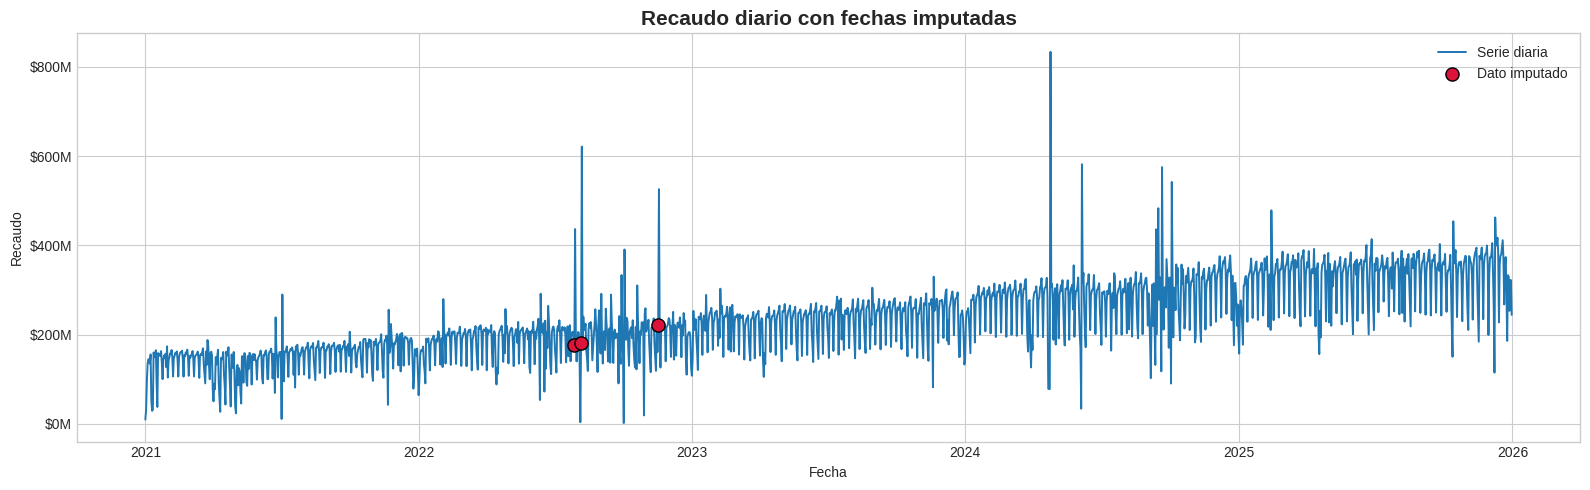

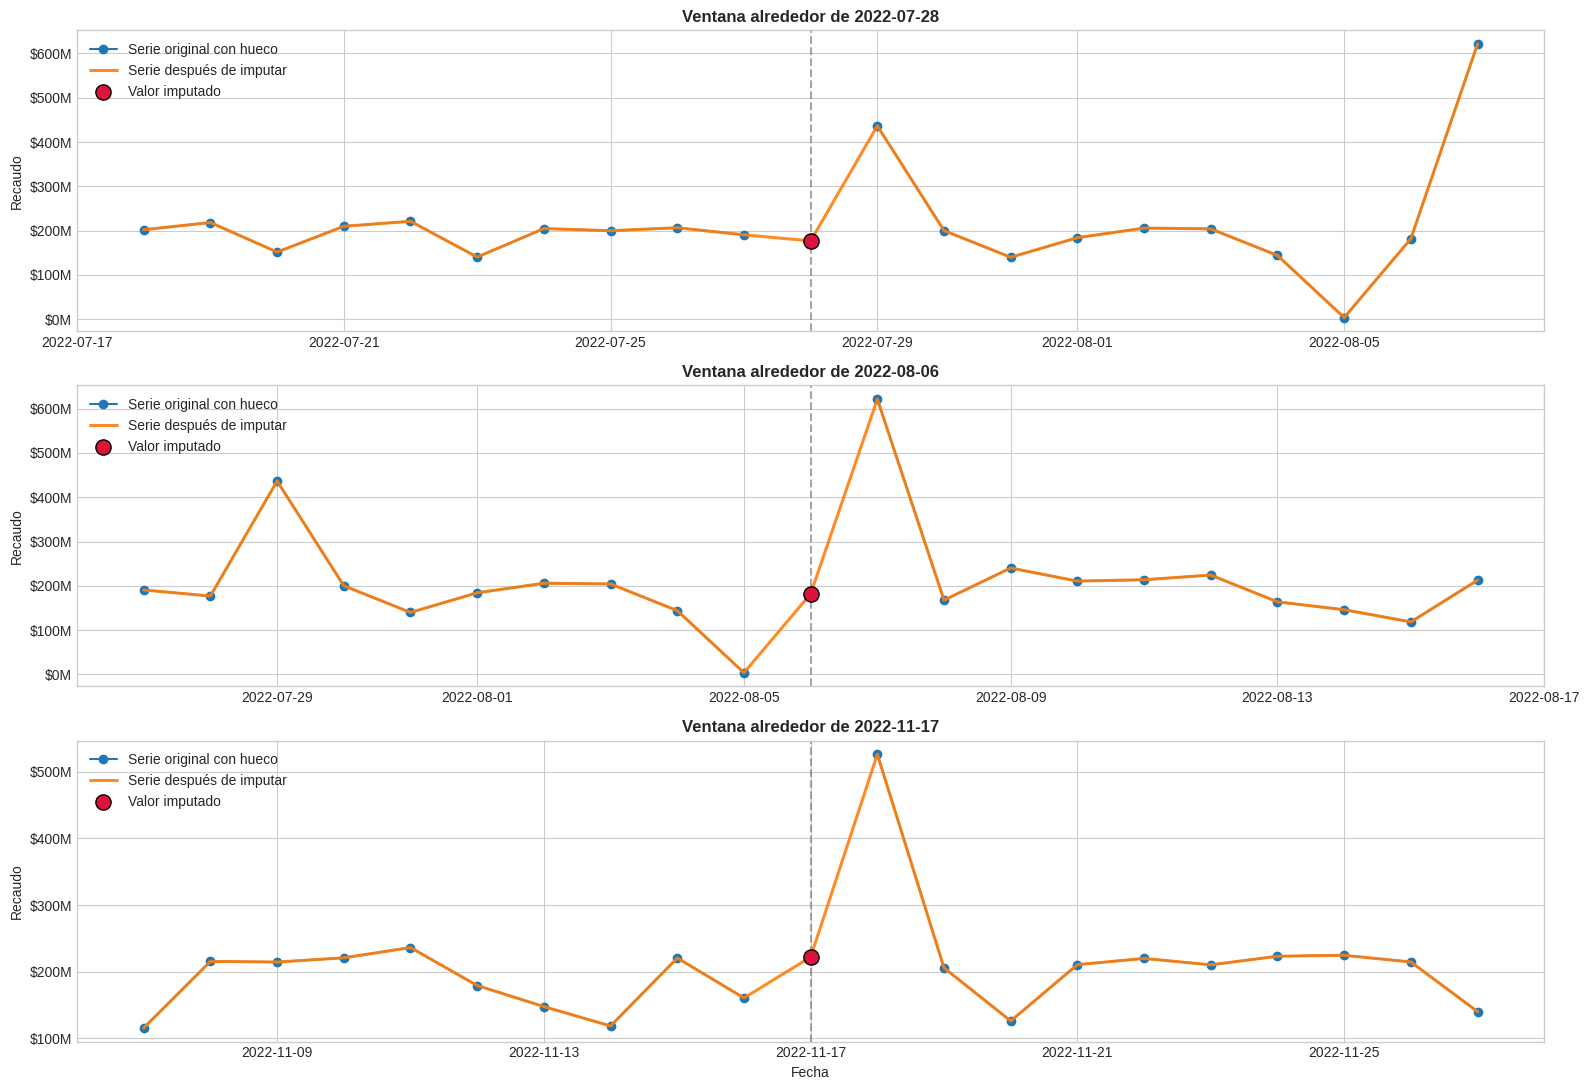

In [21]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
plt.style.use("seaborn-v0_8-whitegrid")

# ------------------------------------------------------------
# 1. Carga de la base
# ------------------------------------------------------------

# Si hace falta subirlo manualmente, se puede usar esto:
from google.colab import files
files.upload()
ruta_excel = "/content/data_peajes.xlsx"

# Cargo la base original
df = pd.read_excel(ruta_excel)

# Estandarizo nombres para evitar errores por tildes o espacios
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.normalize("NFKD")
      .str.encode("ascii", errors="ignore")
      .str.decode("utf-8")
)

# Convierto fecha y ordeno la serie
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print("Dimensión original:", df.shape)
print("\nColumnas detectadas:", df.columns.tolist())
print("\nPrimeras filas:")
display(df.head())

# ------------------------------------------------------------
# 2. Revisión de continuidad diaria
# ------------------------------------------------------------

# Armo un calendario diario completo desde la primera hasta la última fecha
calendario = pd.DataFrame({
    "fecha": pd.date_range(df["fecha"].min(), df["fecha"].max(), freq="D")
})

# Uno la base contra ese calendario para detectar huecos
base = calendario.merge(df, on="fecha", how="left")

# Marco las filas que quedaron vacías por ausencia en la fuente
base["es_imputado"] = base["recaudo"].isna()

faltantes = base.loc[base["es_imputado"], "fecha"].copy()

print("\nFechas faltantes detectadas:")
print(faltantes.dt.strftime("%Y-%m-%d").tolist())

# ------------------------------------------------------------
# 3. Completo el día de la semana desde la fecha
# ------------------------------------------------------------

dias_es = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miercoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sabado",
    "Sunday": "Domingo"
}

base["dia_semana"] = base["fecha"].dt.day_name().map(dias_es)

# ------------------------------------------------------------
# 4. Imputación simple y fácil de explicar
# ------------------------------------------------------------

# Tomo la fecha como índice para usar desplazamientos de 7 días
base = base.set_index("fecha")

# Para cada fecha faltante:
# imputo con el promedio del mismo día de la semana
# de la semana anterior y la siguiente
for fecha in faltantes:
    for col in ["recaudo", "movimientos"]:
        valor_semana_anterior = base.loc[fecha - pd.Timedelta(days=7), col]
        valor_semana_siguiente = base.loc[fecha + pd.Timedelta(days=7), col]
        base.loc[fecha, col] = (valor_semana_anterior + valor_semana_siguiente) / 2

base = base.reset_index()

# Redondeo porque ambas variables deben quedar enteras
base["recaudo"] = base["recaudo"].round(0).astype("int64")
base["movimientos"] = base["movimientos"].round(0).astype("int64")

print("\nValores imputados:")
display(base.loc[base["es_imputado"], ["fecha", "dia_semana", "recaudo", "movimientos"]])

# ------------------------------------------------------------
# 5. Validaciones rápidas
# ------------------------------------------------------------

print("Fechas duplicadas:", base["fecha"].duplicated().sum())
print("Nulos en fecha:", base["fecha"].isna().sum())
print("Nulos en recaudo:", base["recaudo"].isna().sum())
print("Nulos en movimientos:", base["movimientos"].isna().sum())

print("\nSaltos entre fechas después de limpiar:")
display(base["fecha"].diff().dropna().value_counts().to_frame("conteo"))

# ------------------------------------------------------------
# 6. Gráfico general con las fechas imputadas
# ------------------------------------------------------------

def formato_millones(x, pos):
    return f"${x/1e6:,.0f}M".replace(",", ".")

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(base["fecha"], base["recaudo"], linewidth=1.4, label="Serie diaria")
ax.scatter(
    base.loc[base["es_imputado"], "fecha"],
    base.loc[base["es_imputado"], "recaudo"],
    s=90,
    color="crimson",
    edgecolor="black",
    zorder=5,
    label="Dato imputado"
)

ax.set_title("Recaudo diario con fechas imputadas", fontsize=15, weight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Recaudo")
ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Zoom de cada imputación para exposición
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharey=False)

for ax, fecha in zip(axes, faltantes):
    ventana = base[
        (base["fecha"] >= fecha - pd.Timedelta(days=10)) &
        (base["fecha"] <= fecha + pd.Timedelta(days=10))
    ].copy()

    # Recreo la serie con el hueco original para mostrar el antes
    ventana_hueco = ventana.copy()
    ventana_hueco.loc[ventana_hueco["fecha"] == fecha, "recaudo"] = np.nan

    ax.plot(
        ventana_hueco["fecha"],
        ventana_hueco["recaudo"],
        marker="o",
        linewidth=1.5,
        label="Serie original con hueco"
    )

    ax.plot(
        ventana["fecha"],
        ventana["recaudo"],
        linewidth=2.2,
        alpha=0.90,
        label="Serie después de imputar"
    )

    punto = ventana.loc[ventana["fecha"] == fecha]

    ax.scatter(
        punto["fecha"],
        punto["recaudo"],
        s=120,
        color="crimson",
        edgecolor="black",
        zorder=6,
        label="Valor imputado"
    )

    ax.axvline(fecha, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"Ventana alrededor de {fecha.strftime('%Y-%m-%d')}", fontsize=12, weight="bold")
    ax.set_ylabel("Recaudo")
    ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Guardo la base limpia de Fase 1
# ------------------------------------------------------------
base = base.sort_values("fecha").reset_index(drop=True)


# **2. Construcción de variables explicativas**
En esa siguiente etapa se incorporarán potenciales variables explicativas y covariables relevantes para mejorar el pronóstico.

## **2.1. Combustible**

In [22]:
# ============================================================
# EXTRACCIÓN FLEXIBLE DE ACPM, GMC Y GME PARA MEDELLÍN - 2025
# ============================================================

import re
import unicodedata
import pandas as pd
from openpyxl import load_workbook

# ------------------------------------------------------------
# 1. Abro el archivo ya cargado en Colab
# ------------------------------------------------------------

ruta_excel = "/content/SICOM_2025.xlsx"
wb = load_workbook(ruta_excel, data_only=True)

# ------------------------------------------------------------
# 2. Defino funciones de apoyo para buscar de forma flexible
# ------------------------------------------------------------

def normalizar_texto(valor):
    """
    Convierto cualquier texto a una forma comparable:
    - sin tildes
    - en mayúscula
    - sin espacios sobrantes
    """
    if valor is None:
        return ""
    texto = str(valor).strip()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"\s+", " ", texto.upper())
    return texto

def extraer_mes_desde_hoja(nombre_hoja):
    """
    Identifico el mes a partir del nombre de la hoja.
    """
    nombre = normalizar_texto(nombre_hoja)

    meses = {
        "ENERO": 1,
        "FEBRERO": 2,
        "MARZO": 3,
        "ABRIL": 4,
        "MAYO": 5,
        "JUNIO": 6,
        "JULIO": 7,
        "AGOSTO": 8,
        "SEPTIEMBRE": 9,
        "SETIEMBRE": 9,
        "OCTUBRE": 10,
        "NOVIEMBRE": 11,
        "DICIEMBRE": 12,
    }

    for nombre_mes, numero_mes in meses.items():
        if nombre_mes in nombre:
            return numero_mes

    return None

def buscar_fila_seccion(ws, etiqueta):
    """
    Localizo la fila donde empieza cada bloque:
    ACPM, GMC o GME.
    """
    etiqueta = normalizar_texto(etiqueta)

    for fila in ws.iter_rows():
        for celda in fila:
            texto = normalizar_texto(celda.value)

            if etiqueta == "GME":
                if texto in {"GME", "GME*"}:
                    return celda.row
            else:
                if texto == etiqueta:
                    return celda.row

    return None

def buscar_columna_promedio(ws, fila_header):
    """
    Encuentro la columna cuyo encabezado sea 'Promedio'.
    """
    for col in range(1, ws.max_column + 1):
        texto = normalizar_texto(ws.cell(fila_header, col).value)
        if texto == "PROMEDIO":
            return col
    return None

def extraer_valor_medin(ws, fila_seccion):
    """
    Desde la fila de encabezado de una sección, busco la fila de Medellín
    y extraigo el valor de la columna Promedio.
    """
    if fila_seccion is None:
        return None

    col_promedio = buscar_columna_promedio(ws, fila_seccion)
    if col_promedio is None:
        return None

    # Recorro hacia abajo hasta encontrar una fila vacía larga
    # o hasta toparme con otra sección importante
    for fila in range(fila_seccion + 1, min(ws.max_row, fila_seccion + 40) + 1):
        etiqueta_fila = normalizar_texto(ws.cell(fila, 2).value)

        if etiqueta_fila in {"", "PRECIOS SICOM", "ACPM", "GMC", "GME", "GME*"}:
            continue

        if etiqueta_fila == "MEDELLIN":
            valor = ws.cell(fila, col_promedio).value
            if isinstance(valor, (int, float)):
                return float(valor)

    return None

# ------------------------------------------------------------
# 3. Recorro hojas y extraigo Medellín para cada combustible
# ------------------------------------------------------------

registros = []

for nombre_hoja in wb.sheetnames:
    ws = wb[nombre_hoja]

    mes = extraer_mes_desde_hoja(nombre_hoja)
    if mes is None:
        continue

    fila_acpm = buscar_fila_seccion(ws, "ACPM")
    fila_gmc  = buscar_fila_seccion(ws, "GMC")
    fila_gme  = buscar_fila_seccion(ws, "GME")

    acpm = extraer_valor_medin(ws, fila_acpm)
    gmc  = extraer_valor_medin(ws, fila_gmc)
    gme  = extraer_valor_medin(ws, fila_gme)

    registros.append({
        "fecha": pd.Timestamp(year=2025, month=mes, day=1),
        "ACPM": acpm,
        "GMC": gmc,
        "GME": gme
    })

# ------------------------------------------------------------
# 4. Construyo el dataframe final
# ------------------------------------------------------------

df_combustibles = (
    pd.DataFrame(registros)
      .sort_values("fecha")
      .reset_index(drop=True)
)

# Dejo la fecha en formato mes-2025
df_combustibles["fecha"] = df_combustibles["fecha"].dt.strftime("%Y-%m")

print("DataFrame final:")
display(df_combustibles)

# ------------------------------------------------------------
# 5. Validación rápida
# ------------------------------------------------------------

print("\nNulos por columna:")
print(df_combustibles.isna().sum())

DataFrame final:


,fecha,ACPM,GMC,GME
0,2025-01,10883.408542,16869.106302,21036.597701
1,2025-02,10996.409910,16976.912945,21039.581395
2,2025-03,11135.780193,16020.735897,20481.792453
3,2025-04,11097.166667,16008.318841,20507.917910
4,2025-05,11117.779412,16044.805970,21222.968750
5,2025-06,11117.108974,16068.211268,21189.344262
6,2025-07,11159.054545,16041.113208,21159.240000
7,2025-08,11182.225490,16064.573770,21086.684524
8,2025-09,11169.010101,16051.450549,21020.689873
9,2025-10,11229.740000,16109.795699,20902.890244



Nulos por columna:
fecha    0
ACPM     0
GMC      0
GME      0
dtype: int64


In [23]:
# ============================================================
# CONVIERTO EL DATAFRAME MENSUAL DE COMBUSTIBLES A DIARIO
# Y LO UNO CON LA BASE DIARIA DE LA FASE 1
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Reviso tipos y estandarizo la fecha del dataframe mensual
# ------------------------------------------------------------

# Trabajo sobre una copia para no alterar el dataframe original
combustibles_mensual = df_combustibles.copy()

# Aseguro que la fecha quede en formato datetime
# Este bloque soporta fechas tipo "2025-01" o datetime
combustibles_mensual["fecha"] = pd.to_datetime(combustibles_mensual["fecha"], format="%Y-%m", errors="coerce")

# Quito filas con fecha inválida, si aparecieran
combustibles_mensual = combustibles_mensual.dropna(subset=["fecha"]).copy()

# Ordeno por fecha
combustibles_mensual = combustibles_mensual.sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Expando cada mes a frecuencia diaria
# ------------------------------------------------------------

# Creo el rango diario cubierto por los combustibles disponibles
fecha_inicio = combustibles_mensual["fecha"].min()
fecha_fin = combustibles_mensual["fecha"].max() + pd.offsets.MonthEnd(0)

combustibles_diario = pd.DataFrame({
    "fecha": pd.date_range(start=fecha_inicio, end=fecha_fin, freq="D")
})

# Uno por la fecha del primer día de cada mes
combustibles_diario = combustibles_diario.merge(
    combustibles_mensual,
    on="fecha",
    how="left"
)

# Completo hacia adelante para que cada precio mensual
# se replique en todos los días del mismo mes
combustibles_diario[["ACPM", "GMC", "GME"]] = (
    combustibles_diario[["ACPM", "GMC", "GME"]].ffill()
)

#print("DataFrame diario de combustibles:")
#display(combustibles_diario.head(35))

# ------------------------------------------------------------
# 3. Preparo la base diaria para el merge
# ------------------------------------------------------------

base["fecha"] = pd.to_datetime(base["fecha"])
base = base.sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 4. Hago el merge con la base diaria
# ------------------------------------------------------------

base = base.merge(
    combustibles_diario,
    on="fecha",
    how="left"
)

# ------------------------------------------------------------
# 5. Borro filas donde hayan quedado vacíos los combustibles
# ------------------------------------------------------------

base = base.dropna(subset=["ACPM", "GMC", "GME"]).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Validación rápida
# ------------------------------------------------------------

print("Dimensión final de base:", base.shape)
print("\nRango de fechas final:")
print(base["fecha"].min(), "->", base["fecha"].max())

print("\nNulos por columna de combustibles:")
print(base[["ACPM", "GMC", "GME"]].isna().sum())

print("\nVista previa de base con combustibles:")
display(base.head())

Dimensión final de base: (365, 8)

Rango de fechas final:
2025-01-01 00:00:00 -> 2025-12-31 00:00:00

Nulos por columna de combustibles:
ACPM    0
GMC     0
GME     0
dtype: int64

Vista previa de base con combustibles:


,fecha,dia_semana,recaudo,movimientos,es_imputado,ACPM,GMC,GME
0,2025-01-01,Miercoles,157445700,9354,False,10883.408542,16869.106302,21036.597701
1,2025-01-02,Jueves,261963000,12695,False,10883.408542,16869.106302,21036.597701
2,2025-01-03,Viernes,276621800,13199,False,10883.408542,16869.106302,21036.597701
3,2025-01-04,Sabado,259619200,13586,False,10883.408542,16869.106302,21036.597701
4,2025-01-05,Domingo,226524800,12264,False,10883.408542,16869.106302,21036.597701


In [24]:
### 2.1.1. Gráfica combustible

In [25]:
# ============================================================
# GRÁFICA INTERACTIVA DE PRECIOS DE COMBUSTIBLES
# ============================================================

import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Preparo el dataframe para graficar
# ------------------------------------------------------------

# Trabajo sobre una copia para evitar cambios accidentales
comb_plot = combustibles_diario.copy()

# Aseguro formato de fecha
comb_plot["fecha"] = pd.to_datetime(comb_plot["fecha"])

# Quito posibles duplicados si existieran
comb_plot = comb_plot.drop_duplicates(subset=["fecha"]).sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Construyo la gráfica interactiva
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=comb_plot["fecha"],
        y=comb_plot["ACPM"],
        mode="lines",
        name="ACPM",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>ACPM:</b> $%{y:,.0f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=comb_plot["fecha"],
        y=comb_plot["GMC"],
        mode="lines",
        name="GMC",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>GMC:</b> $%{y:,.0f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=comb_plot["fecha"],
        y=comb_plot["GME"],
        mode="lines",
        name="GME",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>GME:</b> $%{y:,.0f}<extra></extra>"
    )
)

# ------------------------------------------------------------
# 3. Ajusto el diseño para que se vea bien en exposición
# ------------------------------------------------------------

fig.update_layout(
    title=dict(
        text="Evolución diaria de precios promedio de combustibles en Medellín (2025)",
        x=0.5,
        xanchor="center"
    ),
    xaxis_title="Fecha",
    yaxis_title="Precio promedio",
    template="plotly_white",
    hovermode="x unified",
    height=600,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=50, r=50, t=90, b=50)
)

fig.update_yaxes(tickprefix="$", separatethousands=True)

# ------------------------------------------------------------
# 4. Agrego controles útiles para explorar la serie
# ------------------------------------------------------------

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=[
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(label="Todo", step="all")
        ]
    )
)

# ------------------------------------------------------------
# 5. Muestro la gráfica
# ------------------------------------------------------------

fig.show()